Тема: исследование данных ВОЗ (World Health Organization) за период с 2000 по 2015 годы.
Цель: Построение модели линейной регрессии для предсказания продолжительности жизни (Life expectancy) на основе экономических и медицинских показателей.

In [123]:
# Ссылка на датасет: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who?select=Life+Expectancy+Data.csv

import pandas as pd
import numpy as np

df = pd.read_csv('Life Expectancy Data.csv', low_memory= False)

#удаление пробелы в начале и конце названий всех столбцов
df.columns = df.columns.str.strip()

display(df.head(20))


display(f'Колличество нулевых строк: {df.isnull().sum().sum()}')
display(f'Колличество дубликатов: {df.duplicated().sum()}')

# заполнение нулевых ячеек
df = df.fillna(df.median(numeric_only= True))
print()
display(f'Колличество нулевых строк после fillna: {df.isnull().sum().sum()}')

# удаление колонки с названиями стран, так как это бедет только мешать
df = df.drop(columns= 'Country')

# кодирование
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['Status'] = label.fit_transform(df['Status'])

display(df.head())


#### Я удалил лишние пробелы в названиях признаков, заполнил пропущенные значения медианой (так как она устойчива к выбросам), 
# удалил столбец Country для обобщения модели и провел кодирование колонки Status

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


'Колличество нулевых строк: 2563'

'Колличество дубликатов: 0'

'Колличество нулевых строк после fillna: 0'

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


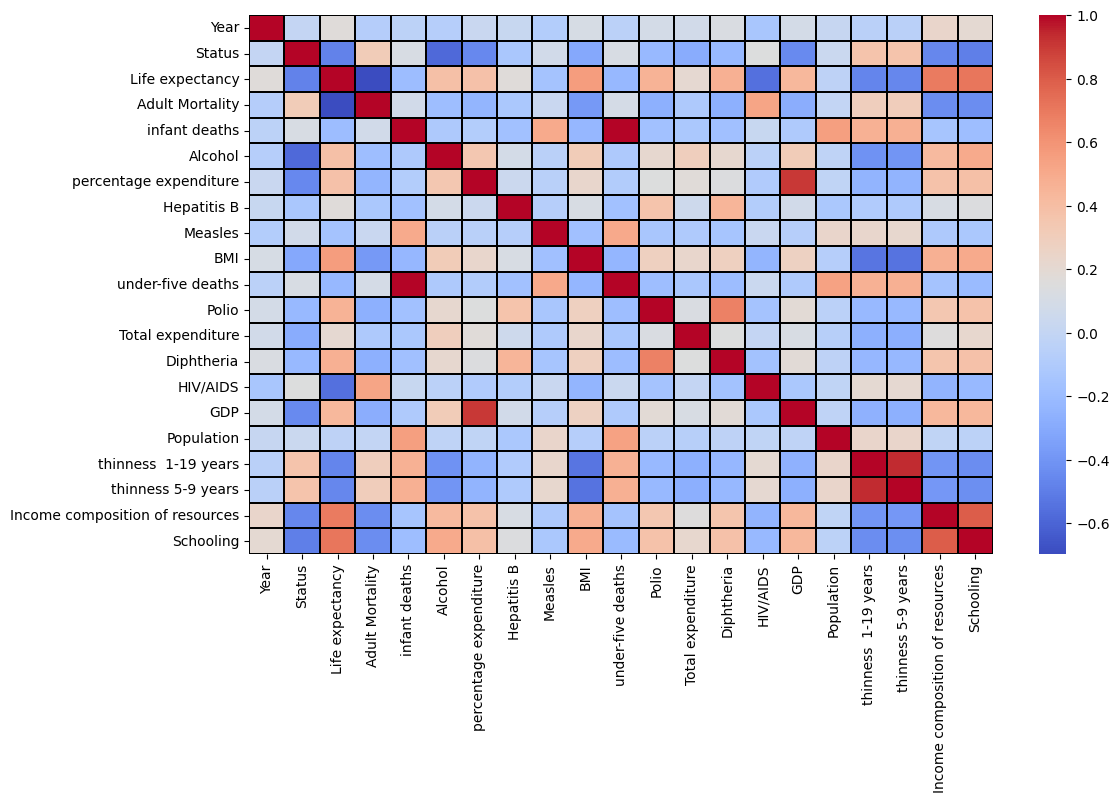

In [124]:
## проверим корреляци признаков
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize= (12, 7))

corr = df[df.columns].corr()

sns.heatmap(
    data= corr,
    annot= False,
    linewidths= 0.1,
    linecolor= 'black',
    cmap= 'coolwarm'
)
plt.show()

#удалим колонку under-five deaths, так как она сильно коррелирует с infant death; а также thinness 5-9 years
df_1 = df.drop(columns= ['under-five deaths', 'thinness 5-9 years'])

## с Life expectancy наибольшую корреляцию имеют колонки BMI, Income composition of resources и Schooling


#### Проведен анализ корреляций между признаками. 
# Из пар сильно связанных переменных (infant deaths и under-five deaths) был оставлен только один признак, чтобы избежать нестабильности весов

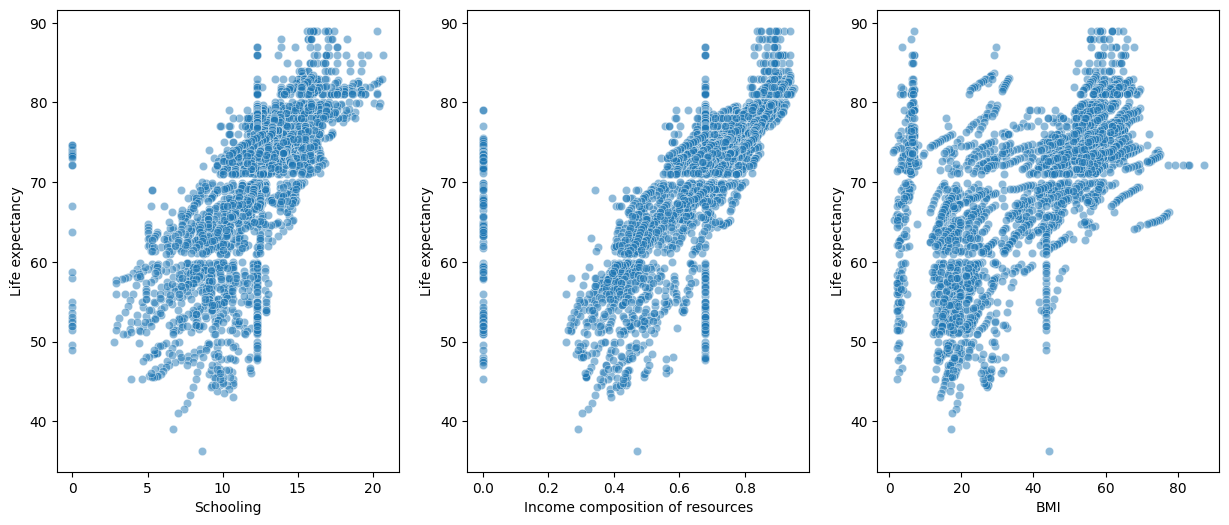

Year                               2000.00000
Status                                0.00000
Life expectancy                      36.30000
Adult Mortality                       1.00000
infant deaths                         0.00000
Alcohol                               0.01000
percentage expenditure                0.00000
Hepatitis B                           1.00000
Measles                               0.00000
BMI                                   1.00000
Polio                                 3.00000
Total expenditure                     0.37000
Diphtheria                            2.00000
HIV/AIDS                              0.10000
GDP                                   1.68135
Population                           34.00000
thinness  1-19 years                  0.10000
Income composition of resources       0.00000
Schooling                             0.00000
Name: min, dtype: float64


In [125]:
# Строим Scatterplots
fig, axes = plt.subplots(1, 3, figsize = (15, 6))

sns.scatterplot(
    data = df_1,
    x = df_1['BMI'],
    y = df_1['Life expectancy'],
    alpha = 0.5, #Прозрачность точек
    ax = axes[2]
)

sns.scatterplot(
    data = df_1,
    x = df_1['Income composition of resources'],
    y = df_1['Life expectancy'],
    alpha = 0.5, #Прозрачность точек
    ax= axes[1]
)

sns.scatterplot(
    data = df_1,
    x = df_1['Schooling'],
    y = df_1['Life expectancy'],
    alpha = 0.5, #Прозрачность точек
    ax= axes[0]
)
plt.show()
#Визуальный анализ показал выраженную положительную линейную зависимость продолжительности жизни от образования и уровня доходов. 
#Самым перспективным признаком для модели является Income composition of resources. 
#Также были обнаружены аномалии (нулевые значения индекса ресурсов), которые могут негативно повлиять на точность модели и требуют обработки.

# Смотрим статистику по всем числовым колонкам
print(df_1.describe().loc['min'])

# Заменяем нули в колонках, где это требуется на медиану значений этой колонки
col_fix = ['percentage expenditure', 'Income composition of resources', 'Schooling']
for i in col_fix:
    median_ = df_1[df_1[i]>0][i].median()
    df_1[i] = df_1[i].replace(0, median_)




#### Визуализация через тепловую карту и Scatterplots выявила сильную линейную связь между продолжительностью жизни и уровнем дохода/образования. 
#### Также были обнаружены аномалии (нули в доходах), требующие коррекции

In [126]:
## Я разделил исходный датасет на обучающую (80%) и тестовую (20%) выборки с помощью функции train_test_split. 
 # Параметр random_state=42 зафиксирован для обеспечения идентичности разбиения при каждом перезапуске кода

## Разделение необходимо для объективной оценки качества модели на данных, которые она «не видела» в процессе обучения. 
 # Если обучать и проверять модель на одном и том же наборе, возникнет эффект переобучения 
 # (модель просто выучит ответы для конкретных строк, но окажется бесполезной при встрече с новыми данными из реального мира.)

test_0 = df_1.drop(columns = 'Life expectancy')
true_0 = df_1['Life expectancy']

### Разделение выборки
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    test_0, true_0, test_size= 0.2, random_state= 42
)

# масштабирование
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().set_output(transform= 'pandas')

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Обучающая выборка: {x_train_scaled.shape}")
print(f"Тестовая выборка: {x_test_scaled.shape}")

# Обучение модели
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(x_train_scaled, y_train)
pred = model.predict(x_test_scaled)

# интерпритация важности каждого фактора
weights = pd.Series(model.coef_, index=x_train_scaled.columns)
print()
print(weights.sort_values(ascending=False))

### 1. Положительные веса
#Income composition of resources (4.04): Вес 4.04 означает, что при росте индекса ресурсов на 1 стандартное отклонение, продолжительность жизни вырастает сразу на 4 года. Это доказывает, что экономическая стабильность — фундамент здоровья.
#Diphtheria (1.01): Очень важный медицинский вывод. Уровень вакцинации от дифтерии (и полиомиелита чуть ниже) напрямую добавляет годы к жизни. Это чистая медицина в данных.
#Schooling (0.54): Образование тоже в плюсе. Умные люди живут дольше (лучше гигиена, меньше вредных привычек, лучше работа).

### 2. Отрицательные веса
#Adult Mortality (-2.37): Ожидаемо, высокая смертность среди взрослых «тянет» прогноз вниз на 2.3 года.
#HIV/AIDS (-2.07): Еще один негативный фактор. В странах с эпидемией ВИЧ жизнь сокращается на 2 года по формуле модели.

### 3. Странности
#GDP (-0.22): Возможно признак Income уже забрал на себя всё влияние денег, а оставшийся GDP стал «шумом»
#Hepatitis B (-0.56): Скорее всего, это говорит о том, что массовая вакцинация от гепатита B чаще проводится в бедных, развивающихся странах (где жизнь короче сама по себе). Модель увидела эту ложную корреляцию.

Обучающая выборка: (2350, 18)
Тестовая выборка: (588, 18)

Income composition of resources    4.044406
Diphtheria                         1.010953
Schooling                          0.540999
Polio                              0.496821
BMI                                0.487510
percentage expenditure             0.408179
Total expenditure                  0.321583
Year                               0.283779
Population                         0.132512
infant deaths                     -0.085140
thinness  1-19 years              -0.108209
Alcohol                           -0.159062
GDP                               -0.224437
Hepatitis B                       -0.562586
Measles                           -0.568293
Status                            -0.570309
HIV/AIDS                          -2.069312
Adult Mortality                   -2.369906
dtype: float64


In [131]:
# Результаты
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f'MAE: {mean_absolute_error(y_test, pred):.2f}') # Средняя ошибка в годах
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.2f}') # Корень из среднеквадратичной ошибки. Она сильнее штрафует за большие промахи
print(f'R2: {r2_score(y_test, pred):.4f}') # Это число от 0 до 1. Оно показывает, какой процент «вариативности» данных объясняет твоя модель

### Все значения более-менее приемлимы
### Все финальные метрики считались на тестовой выборке


#Проверка на переобучение 
r2_train = r2_score(y_train, model.predict(x_train_scaled))
print()
print(f"R2 на тренировке: {r2_train:.4f}")
print(f"R2 на тесте: {r2_score(y_test, pred):.4f}")

## Доказательство отсутствия переобучения
# Разница всего в 0.0045 (меньше 1%). Модель работает на новых данных так же хорошо, как и на тех, что видела при обучении.

MAE: 2.74
RMSE: 3.87
R2: 0.8273

R2 на тренировке: 0.8318
R2 на тесте: 0.8273


In [130]:
## Создаем базовую модель DummyRegressor
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor()
dummy.fit(x_train_scaled, y_train)
dummy_pred = dummy.predict(x_test_scaled)

print(f'MAE для Dummy: {mean_absolute_error(y_test, dummy_pred):.2f}')
print(f'RMSE для Dummy: {np.sqrt(mean_squared_error(y_test, dummy_pred)):.2f}') 
print(f'R2 для Dummy: {r2_score(y_test, dummy_pred):.4f}')

# Данная 'глупая' версия имеет намного большие ошибки, что подтверждает нормальную работу созданной перед этим модели

MAE для Dummy: 7.65
RMSE для Dummy: 9.31
R2 для Dummy: -0.0008


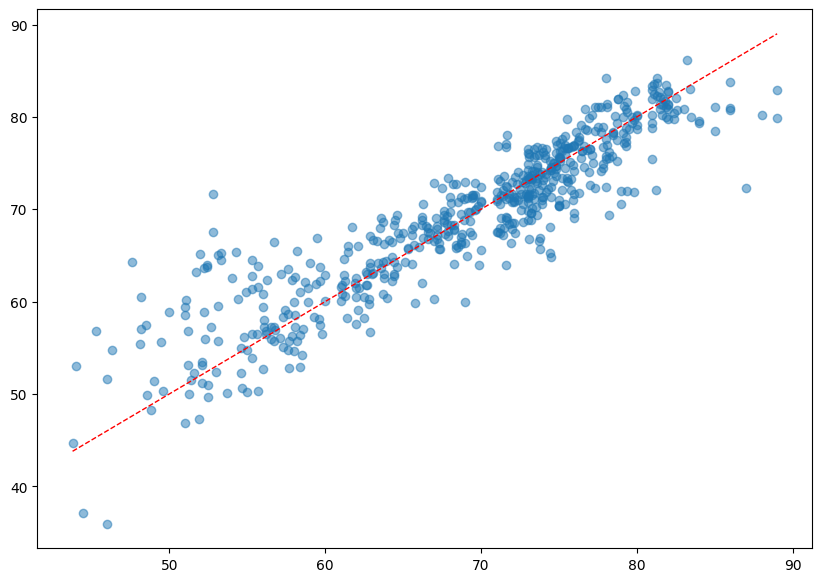

In [129]:
## Визуализация 'предсказание модели - реальность'
plt.figure(figsize=(10, 7))
plt.scatter(
    x = y_test,
    y = pred,
    alpha= 0.5
)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', # красная пунктирная линия
    lw = 1 # толщина этой линии
)
